# Intron Analysis v1

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(viridis)

── Attaching packages ───────────────────────────────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.8
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ──────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: viridisLite



In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
intron_data <- read.csv("input//intron_analysis/all_stats.csv") %>% rename(sample=subject)

- **total_reads** total number of umi
- **target_region_reads** reads that cover the intron position
- **spliced_reads** splicing reads
- **intronic reads** reads in intron (at least 5 nt)
- **unsure_reads** reads in the region but did not match the criteria

In [4]:
head(intron_data,25)

,sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_mediandepth,intron_depths
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,K1B_S10000,LC,TTAGGCAGTCGAACAG,AAACCCGGCA,35,28,28,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
2,K1B_S10000,LC,TTAGGCAGTCGAACAG,AAGACTATGA,63,53,53,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
3,K1B_S10000,LC,TTAGGCAGTCGAACAG,ACGTATATGG,92,76,76,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
4,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGAAAATCGC,89,69,69,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
5,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGGGTACGC,69,57,57,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
6,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGTGTGCCT,21,2,0,2,0,2,2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2
7,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGTTAGTCTT,54,39,39,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
8,K1B_S10000,LC,TTAGGCAGTCGAACAG,ATAACGCTTC,67,56,56,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
9,K1B_S10000,LC,TTAGGCAGTCGAACAG,ATATTGTGCA,75,54,54,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


In [5]:
length(unique(intron_data$cell))

[1] 76

In [6]:
# events until filter 4
df <- read.csv("output/df_f4.csv") %>% mutate(sample=gsub(".{3}$", "", subject))
head(df)

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000


In [7]:
length(unique(df$cell))

[1] 102

In [8]:
# #events all filter
# df_summary <- read.csv("output/df_summary.csv")
# head(df_summary)

In [9]:
# cell with SHM events
#cell_shm <- intersect(df %>% select(cell), intron_data %>% select(cell))

#Select cell from intron data (76)
cell_shm_intron <- intron_data %>% pull(cell) %>% unique()

In [10]:
df_intron <- df %>% left_join(intron_data, c("cell","umi","sample")) %>% filter(cell %in% cell_shm_intron)#%>% filter(is.na(mediandepth))
head(df_intron)

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,⋯,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_mediandepth,intron_depths
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,⋯,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,⋯,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


In [11]:
length(unique(df_intron$cell))

[1] 71

In [12]:
cell_shm <- df_intron %>% pull(cell) %>% unique()
cell_shm

[1] "TTAGGCAGTCGAACAG" "AACTCTTGTGCAACTT" "CATCAGAAGCGAAGGG" "GCACATATCTCTAGGA"
 [5] "CGATCGGAGCTACCTA" "AACTCAGCATTCGACA" "AGTGTCACAGCTGGCT" "TTATGCTCATCCTTGC"
 [9] "AGTGAGGGTCGATTGT" "GATGCTATCTTCCTTC" "ACACCCTCACACCGCA" "ACGCAGCAGCAGGCTA"
[13] "ACGCCAGAGGCATTGG" "CACACCTGTTGTGGAG" "ACTGTCCCAGCTGGCT" "ATCATGGGTGGTCTCG"
[17] "GCACATATCGCTTAGA" "AGGTCATCAGTTCCCT" "ATGAGGGGTGTATGGG" "CAACCAAAGTTACGGG"
[21] "CAACCTCGTCTGATTG" "CAAGAAAAGTCCGGTC" "CAAGTTGCAGCTGTGC" "CACAGTACAGGATCGA"
[25] "CACATAGTCATACGGT" "CAGCGACCACAGCGTC" "CCAATCCTCGGAAATA" "CCACTACTCAGTTTGG"
[29] "CCTACCATCATGCATG" "GATCTAGTCGCCGTGA" "CCTTCCCTCTCGCATC" "GTAGGCCTCTGAGTGT"
[33] "GGAATAAGTCTCTCGT" "GGCCGATAGATTACCC" "GTCACAACAACGATCT" "TCTTTCCGTCTAGTCA"
[37] "TGCTGCTGTACAGTGG" "TGTGGTAAGGCGACAT" "TTATGCTCACACCGAC" "TTTCCTCCACTTAAGC"
[41] "ATAACGCCAAGCCGCT" "TAAACCGAGGATGGTC" "GTAACTGCAATCCAAC" "CCACTACGTTAAGTAG"
[45] "CAAGAAAGTCTCCACT" "CGGACTGAGCTGAAAT" "GAGCAGATCTAACTGG" "GTTCTCGCAAGCTGAG"
[49] "GATCAGTAGTAACCCT" "TACCTATAGCGATCCC" "AACTCAGCAAATCCGT" "AACTCCCAGATATACG"
[53] "CACCAGGGTTCGCTAA" "CCATGTCCACCAGGCT" "CGGCTAGTCCTTGACC" "GAGGTGAAGTGGACGT"
[57] "TGGCTGGGTAGTAGTA" "TACCTATAGGTTCCTA" "AAATGCCTCTGAAAGA" "GTGTTAGAGGGAACGG"
[61] "GATCGTATCCCATTTA" "AACACGTAGCCACCTG" "AGCGTATTCTGAAAGA" "AACTCCCAGCGATATA"
[65] "CGCGGTATCAGGCAAG" "GGCTGGTTCCCACTTG" "ATTGGACCACACCGCA" "TAAGAGATCAAACCGT"
[69] "CACCACTAGCCTCGTG" "TGTTCCGTCGGCGCAT" "CGACCTTGTTCCAACA"

In [13]:
# options(repr.matrix.max.cols = 150)
# df_intron_ov <- df_intron %>% filter(mediandepth >0) %>% mutate(match=if_else(nucl == nucl_po, "same_2_po","diff_2_po"))

# head(df_intron_ov)                                                      

In [14]:
options(repr.matrix.max.cols = 150)
df_intron_ov <- df_intron %>% mutate(intron_state=case_when(spliced_reads > intronic_reads ~ "spliced",
                                                   spliced_reads == intronic_reads ~ "unknown",
                                                   spliced_reads < intronic_reads ~ "unspliced",
                                                   TRUE ~ "na")) %>%
               mutate(match=if_else(nucl == nucl_po, "same_2_po","diff_2_po"))

head(df_intron_ov)  

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_mediandepth,intron_depths,intron_state,match
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,diff_2_po
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,diff_2_po
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,diff_2_po
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,same_2_po
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,diff_2_po
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,same_2_po


In [15]:
# p<-ggplot(df_intron_ov, aes(x=match, y=mediandepth,color=match)) + 
#   geom_boxplot(color="black")+
#    geom_jitter(position=position_jitter(0.2)) +
#    scale_color_brewer(palette="Dark2") 
# p

# fig_save(p, filename ="figs/FL/intron_po", formats = c("pdf", "png"), width = 10, height =15, units = "cm", dpi = 320)

In [16]:
intron_perc <- df_intron_ov %>%  group_by(cell) %>% count(intron_state,match) %>%#summarise(median_intron=n(mediandepth)) 
               group_by(cell) %>%
               mutate(Perc_intron =n * 100 / sum(n)) 

In [17]:
#define gene order for plotting
cell_order <- intron_perc %>% group_by(cell,intron_state) %>% arrange(-Perc_intron) %>% pull(cell) %>% unique()

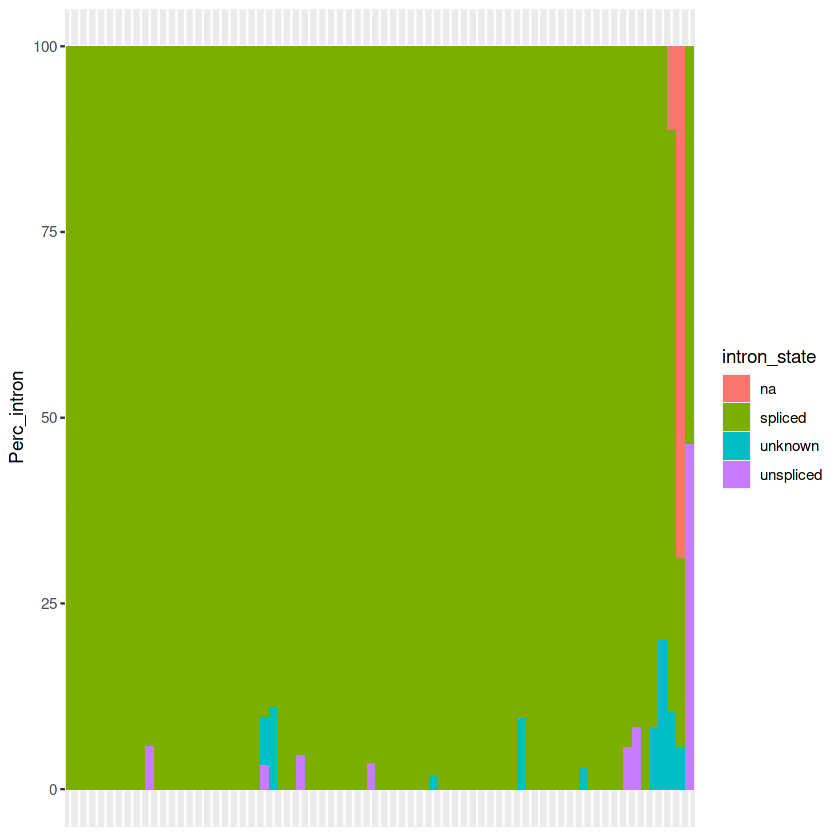

In [18]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_intron, fill=intron_state)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [19]:
cell_intron <- intron_perc %>% filter(intron_state == "unspliced") %>% pull(cell)
cell_intron

[1] "AACTCAGCAAATCCGT" "AACTCAGCAAATCCGT" "AGTGAGGGTCGATTGT" "CAACCTCGTCTGATTG"
[5] "CGGCTAGTCCTTGACC" "GATGCTATCTTCCTTC" "GGCCGATAGATTACCC" "GTCACAACAACGATCT"

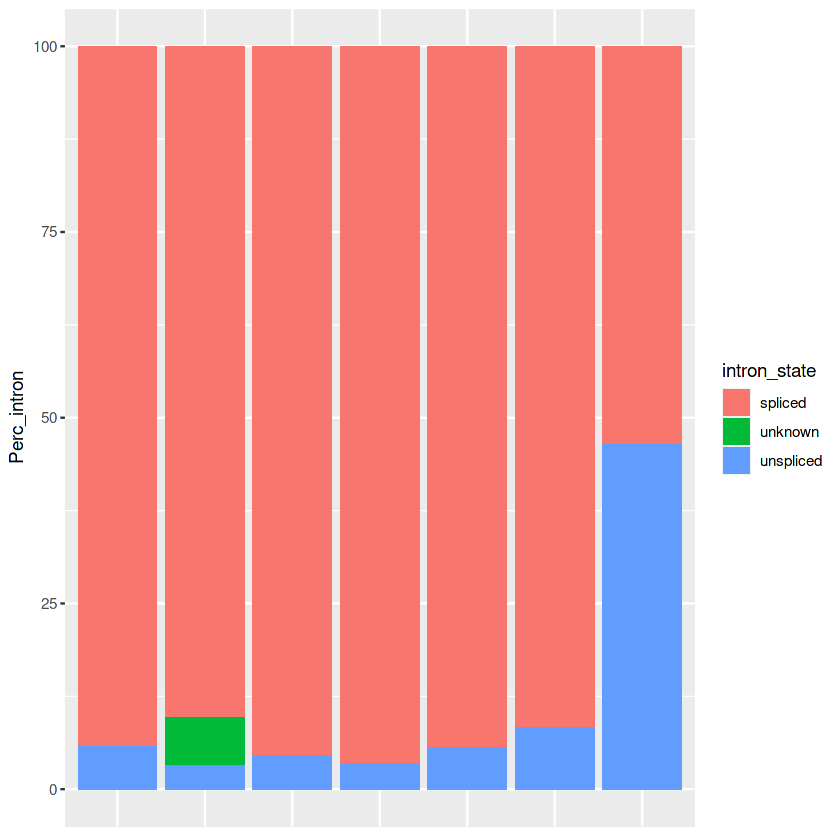

In [20]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc  %>% filter(cell %in% cell_intron) %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_intron, fill=intron_state)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell_filter", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

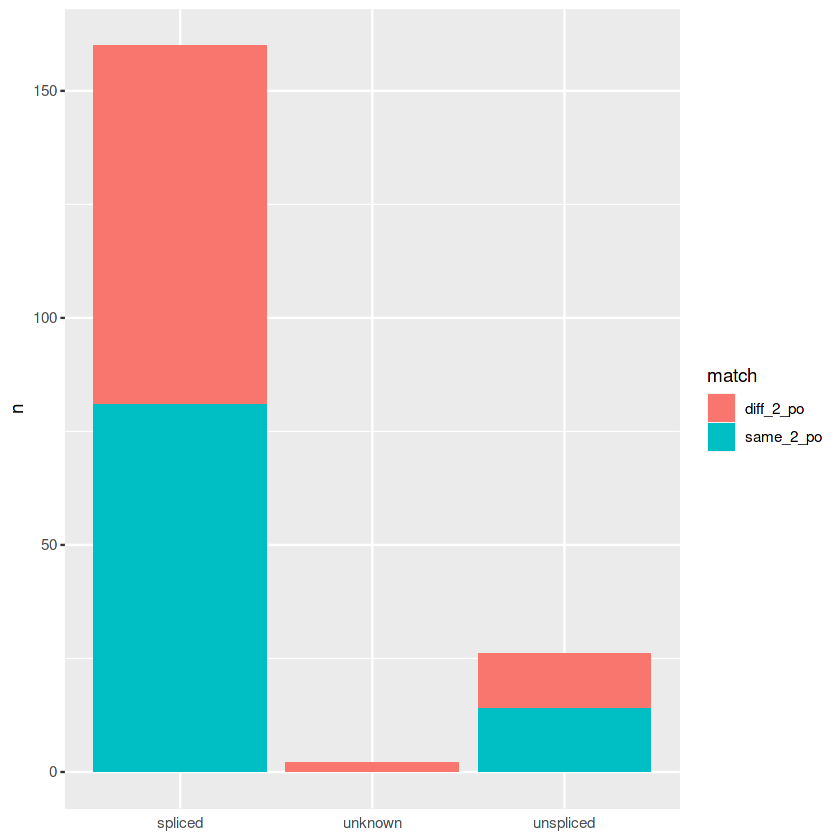

In [21]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc  %>% filter(cell %in% cell_intron) %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=intron_state, y=n, fill=match)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
#        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) 

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell_filter_intron_status", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

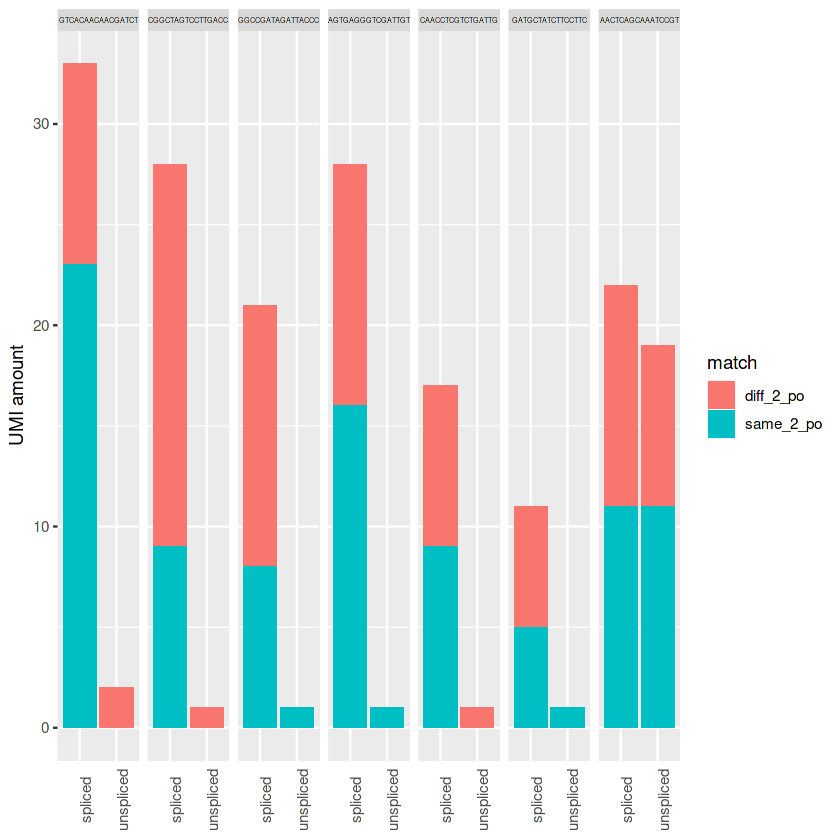

In [22]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc  %>% filter(cell %in% cell_intron, !intron_state  == "unknown") %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=intron_state, y=n, fill=match)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        strip.text.x = element_text(size = 4),
        axis.text.x=element_text(angle = 90),
        axis.ticks.x=element_blank()) +
        ylab("UMI amount") +
        facet_grid(~cell)

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell_filter_by cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [23]:
intron_perc  %>% filter(cell %in% cell_intron)

cell,intron_state,match,n,Perc_intron
<chr>,<chr>,<chr>,<int>,<dbl>
AACTCAGCAAATCCGT,spliced,diff_2_po,11,26.829268
AACTCAGCAAATCCGT,spliced,same_2_po,11,26.829268
AACTCAGCAAATCCGT,unspliced,diff_2_po,8,19.512195
AACTCAGCAAATCCGT,unspliced,same_2_po,11,26.829268
AGTGAGGGTCGATTGT,spliced,diff_2_po,12,41.379310
AGTGAGGGTCGATTGT,spliced,same_2_po,16,55.172414
AGTGAGGGTCGATTGT,unspliced,same_2_po,1,3.448276
CAACCTCGTCTGATTG,spliced,diff_2_po,8,44.444444
CAACCTCGTCTGATTG,spliced,same_2_po,9,50.000000


In [24]:
c <- intron_data %>% filter(cell == "AACTCAGCAAATCCGT", chain == "HC")
str(c)

'data.frame':	65 obs. of  11 variables:
 $ sample             : chr  "K2B_S13530" "K2B_S13530" "K2B_S13530" "K2B_S13530" ...
 $ chain              : chr  "HC" "HC" "HC" "HC" ...
 $ cell               : chr  "AACTCAGCAAATCCGT" "AACTCAGCAAATCCGT" "AACTCAGCAAATCCGT" "AACTCAGCAAATCCGT" ...
 $ umi                : chr  "AAGAACGACG" "AAGGCGAGCC" "AATTAGCATG" "ACACCATTGT" ...
 $ total_reads        : int  2 24 58 131 108 128 3 1 71 22 ...
 $ target_region_reads: int  1 21 14 96 27 34 1 0 17 13 ...
 $ spliced_reads      : int  1 21 14 0 27 34 1 0 17 0 ...
 $ intronic_reads     : int  0 0 0 96 0 0 0 0 0 13 ...
 $ unsure_reads       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ intron_mediandepth : int  0 0 0 21 0 0 0 0 0 3 ...
 $ intron_depths      : chr  "0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0"| __truncated__ "0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0"| __truncated_

In [25]:
df_intron %>% filter(cell == "AACTCAGCAAATCCGT")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_mediandepth,intron_depths
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
AACTCAGCAAATCCGT,ACACCATTGT,133,G,G,GT.AA,103,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,131,96,0,96,0,21,96;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;2;75;75;75;75;77;78;78;79;81;82;83;83;83;83;83;84;85;85;85;86;86;87;86;87;88;88;88;88;87;87;87;87;88;89;87;87;87;86;83;82;79;78;71;18;18;18;18;18;19;19;20;20;20;21;21;21;21;21;21;21;21;21;21;21;21;21;19;19;19
AACTCAGCAAATCCGT,ACCTCTTGGT,133,G,A,GT.AA,28,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,108,27,27,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
AACTCAGCAAATCCGT,ACGCGGGACC,133,G,A,GT.AA,37,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,128,34,34,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
AACTCAGCAAATCCGT,ACTTCGGGTG,133,G,G,GT.AA,28,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,102,28,0,27,1,14,29;2;2;3;4;4;4;5;5;5;5;5;6;6;7;7;7;7;7;7;7;7;9;8;8;8;9;10;10;10;10;10;10;10;10;10;11;11;11;11;12;12;12;13;13;13;13;13;13;14;14;14;13;14;15;16;17;17;18;17;17;17;17;17;17;17;18;18;18;18;18;18;18;17;17;17;17;18;18;18;18;18;19;19;19;19;19;19;19;17;18;18;18;18;18;18;18;17;16;16;16;16;16
AACTCAGCAAATCCGT,ATCGACGCGC,133,G,G,GT.AA,27,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,100,26,1,21,4,10,27;6;6;6;6;6;6;7;7;6;5;5;5;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;5;5;7;7;7;8;9;9;10;10;10;10;9;9;9;9;9;10;11;11;11;11;11;11;11;11;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;11;12;12;12;12;12;13;13;13;13;13;13;13;13;12;12;12;12;12;12;12;12;12;12;12;12
AACTCAGCAAATCCGT,ATCGGTCGAG,133,G,G,GT.AA,25,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,113,27,1,25,1,9,34;9;9;9;8;7;7;8;8;8;6;7;7;7;7;8;7;7;7;7;7;7;7;7;6;6;6;6;7;8;8;8;8;10;11;11;11;10;10;10;11;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;8;8;8;8;8;7;7;7;8;8;8;8;8;8;8;8;7;7;8;9;9;9;9;9;12;12;12;12;12;12;12;12;12;13;13;13;12;12;12;12;12;12;12;12
AACTCAGCAAATCCGT,CATGTGCATC,133,G,G,GT.AA,88,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,115,87,87,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
AACTCAGCAAATCCGT,CTGGGTGCGC,133,G,A,GT.AA,50,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,59,44,44,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
AACTCAGCAAATCCGT,GCGGGAGGAA,133,G,A,GT.AA,95,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,110,88,88,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


### Using all the umis for the particular cell

In [30]:
intron_perc <- intron_data %>%   group_by(cell) %>% count(intron_mediandepth) %>% #filter(!is.na(cell)) %>% #summarise(median_intron=n(mediandepth)) 
        mutate(intron=if_else(intron_mediandepth == 0, "no_intron","intron")) %>%
        group_by(cell) %>%
        mutate(Perc_intron =n * 100 / sum(n)) 

intron_perc

length(unique(intron_perc$cell))

cell,intron_mediandepth,n,intron,Perc_intron
<chr>,<int>,<int>,<chr>,<dbl>
AAAGATGAGACTTGAA,0,31,no_intron,100.000000
AAATGCCTCTGAAAGA,0,100,no_intron,100.000000
AACACGTAGCCACCTG,0,50,no_intron,100.000000
AACACGTAGGACGAAA,0,27,no_intron,100.000000
AACTCAGCAAATCCGT,0,45,no_intron,69.230769
AACTCAGCAAATCCGT,1,1,intron,1.538462
AACTCAGCAAATCCGT,3,2,intron,3.076923
AACTCAGCAAATCCGT,4,1,intron,1.538462
AACTCAGCAAATCCGT,5,3,intron,4.615385


[1] 76

In [31]:
intron_perc %>% filter(cell == "AACTCCCAGATATACG")

cell,intron_mediandepth,n,intron,Perc_intron
<chr>,<int>,<int>,<chr>,<dbl>
AACTCCCAGATATACG,0,44,no_intron,100


In [32]:
intron_data %>% filter(cell == "AACTCCCAGATATACG")

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_mediandepth,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
K2B_S13530,HC,AACTCCCAGATATACG,AAAGTAGCGT,1,0,0,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,ACCAAGTAAG,158,128,128,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,ACGAACAAGA,89,23,23,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,ACGACGGGAC,85,26,26,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,ACGCTAGCAC,39,12,12,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,AGGCGCAAAC,115,30,30,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,AGTAAGCAAC,101,21,21,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,CAAGCTCAGG,204,56,56,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K2B_S13530,HC,AACTCCCAGATATACG,CACGGTAGGG,115,25,25,0,0,0,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


In [33]:
#define gene order for plotting
cell_order <- intron_perc %>% arrange(-Perc_intron) %>% pull(cell) %>% unique()

In [ ]:

# Stacked barplot with multiple groups
intron_plot_cont <- intron_perc %>% mutate(cell = factor(cell, levels = cell_order)) %>%
ggplot( aes(x=cell, y=Perc_intron, fill=mediandepth)) +
  geom_bar(stat="identity")  +
   scale_fill_continuous(low="grey", high="blue") +
   theme(axis.text.y = element_text(size = 5)) +
   coord_flip() +
  labs(y= "umi (%)", x="cells",fill = "Median reads") 
#  scale_fill_viridis()

intron_plot_cont

fig_save(intron_plot_cont, filename ="figs/FL/intron_cell_cont_all_umis", formats = c("pdf", "png"), width = 22, height =17, units = "cm", dpi = 320)

In [ ]:
#number cell without introns
intron_perc %>% filter(intron == "no_intron", Perc_intron == 100 ) %>% pull(cell) %>% unique() %>% length()